# Bitcoin Savings Plan

Companion to **[Should I Buy Bitcoin?](https://newsletter.secretsatoshis.com/p/should-i-buy-bitcoin)**

The strategy in one line: **treat Bitcoin as savings, not as a trade.** A fixed slice of income goes in on an accumulation
schedule, automatically.

### How to use it

1. Set your plan in **Section 1** — start date, income, split, cadence.
2. Run the notebook top to bottom.
3. Read **Section 5**, the dashboard.
4. Run `scripts/update_data.py` to refresh the shared data, then rerun this offline notebook.

### What it does and doesn't do

It reports **what your plan has done to date** on real price history: sats accumulated, average price paid,
value against contributions, and a like-for-like cash scenario at the APY you set.

It does **not** forecast a price, and it makes no claim about whether the result will be positive or
negative — that depends entirely on your start date, your cadence, and what the market did. Every number
below is computed from your inputs. Change them and the conclusions change with them.

*Assumptions: fixed nominal contributions; results are nominal, pre-fee and pre-tax.*

In [1]:
import hashlib
import json
from pathlib import Path
import sys

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "src/bitcoin_investment_strategy").is_dir()), None)
if ROOT is None:
    raise ValueError("Run this notebook from the repository or its notebooks directory")
sys.path.insert(0, str(ROOT / "src"))
from bitcoin_investment_strategy.savings import (
    validate_allocations, prepare_prices, milestone_status, money_weighted_return,
    run_plan as simulate_plan,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter, NullFormatter, FixedLocator

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams.update({
    "figure.figsize": (11, 5.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12.5, "axes.titleweight": "bold", "axes.titlepad": 10,
    "axes.labelsize": 10, "font.size": 10,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "legend.frameon": True, "legend.framealpha": 0.92, "legend.facecolor": "white",
    "legend.edgecolor": "#DDDDDD", "legend.fontsize": 9,
    "figure.autolayout": False,
})
ORANGE, BLUE, GREEN, GREY, RED, PURPLE = "#F7931A", "#2E6FB7", "#2E8B57", "#8A8A8A", "#C0392B", "#7D5BA6"

def usd(v, _=None):
    if v is None or not np.isfinite(v):
        return "—"
    a, sign = abs(v), "-" if v < 0 else ""
    if a < 0.005: return "$0"
    if a >= 1e12: return f"{sign}${a/1e12:,.2f}T"
    if a >= 1e9:  return f"{sign}${a/1e9:,.1f}B"
    if a >= 1e6:  return f"{sign}${a/1e6:,.2f}M"
    if a >= 1e3:  return f"{sign}${a/1e3:,.1f}k"
    if a >= 1:    return f"{sign}${a:,.0f}"
    return f"{sign}${a:,.2f}"

def sats(btc):
    return f"{btc*1e8:,.0f}"


def money_axis(ax, log=False):
    # Dollar labels on the major ticks. Call this AFTER plotting so the limits are known.
    #
    # Log axes need care: matplotlib labels the minor ticks too (the "9 x 10^4" style),
    # which clashes with formatted majors. Silencing them is right when the data spans
    # several decades, but a series covering less than one decade would then be left with
    # a single label, so in that case we place our own rounded ticks across the range.
    if log:
        lo, hi = ax.get_ylim()
        ax.yaxis.set_minor_formatter(NullFormatter())
        if lo > 0 and np.log10(hi / lo) < 1.3:
            edges = np.geomspace(lo, hi, 6)
            ticks = sorted({float(f"{t:.2g}") for t in edges})
            ticks = [t for t in ticks if lo <= t <= hi]
            if len(ticks) >= 3:
                ax.yaxis.set_major_locator(FixedLocator(ticks))
    ax.yaxis.set_major_formatter(FuncFormatter(usd))
    return ax


def date_axis(ax, index, rotate=0):
    # One date convention everywhere, with tick density chosen from the span shown.
    days = (index[-1] - index[0]).days
    if days > 365 * 10:
        loc, fmt = mdates.YearLocator(2), mdates.DateFormatter("%Y")
    elif days > 365 * 4:
        loc, fmt = mdates.YearLocator(), mdates.DateFormatter("%Y")
    elif days > 365 * 1.5:
        loc, fmt = mdates.MonthLocator(interval=3), mdates.DateFormatter("%b %Y")
    else:
        loc, fmt = mdates.MonthLocator(interval=2), mdates.DateFormatter("%b %Y")
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(fmt)
    if rotate:
        for lbl in ax.get_xticklabels():
            lbl.set_rotation(rotate)
            lbl.set_ha("right")
    return ax


def spaced_levels(levels, top, min_gap_frac=0.07):
    # Keep only reference lines that fit on the axis and sit far enough apart to label.
    kept, last = [], None
    for lvl, label in sorted(levels):
        if lvl > top:
            continue
        if last is not None and (lvl - last) < top * min_gap_frac:
            continue
        kept.append((lvl, label)); last = lvl
    return kept


print("Ready.")

Ready.


## 1. Your plan

**Set your numbers here.** The defaults follow the article — a household saving 20% of income, split evenly
between Bitcoin and cash — but every field is yours to change.

| Field | What it means |
|---|---|
| `ANNUAL_INCOME` | Fixed nominal household income the percentages apply to |
| `PCT_TO_BITCOIN` | Share of income bought as BTC on schedule |
| `PCT_TO_CASH` | Share of income into a savings account |
| `CASH_APY` | What that savings account pays annually |
| `BUY_CADENCE` | `"weekly"`, `"biweekly"` or `"monthly"` |
| `PLAN_START` | When you started — or when you want the simulation to begin |
| `STILL_BUYING` | `True` keeps contributing to today; `False` stops after `STOP_AFTER_YRS` |

`ANNUAL_INCOME` stays fixed for the simulation; update it when your income changes.

Your start date is the single most influential choice here. A plan begun at a different point in the cycle
will show a very different picture, and that's the honest behaviour of the strategy, not a quirk of the
notebook.

In [2]:
# ========================= YOUR PLAN — EDIT THIS =========================
ANNUAL_INCOME   = 100_000                    # household gross income
PCT_TO_BITCOIN  = 0.10                       # share of income into BTC
PCT_TO_CASH     = 0.10                       # share of income into a savings account
CASH_APY        = 0.03                       # what the savings account pays annually
BUY_CADENCE     = "monthly"                  # "weekly" | "biweekly" | "monthly"
PLAN_START      = pd.Timestamp("2026-01-01") # when you started (or would have)
STILL_BUYING    = True                       # True = contributions continue to today
STOP_AFTER_YRS  = None                       # if STILL_BUYING is False, stop after this many years
# =========================================================================

validate_allocations(ANNUAL_INCOME, PCT_TO_BITCOIN, PCT_TO_CASH, CASH_APY)

ANNUAL_BTC  = ANNUAL_INCOME * PCT_TO_BITCOIN
ANNUAL_CASH = ANNUAL_INCOME * PCT_TO_CASH

print(f"{PCT_TO_BITCOIN:.0%} of ${ANNUAL_INCOME:,} -> Bitcoin   ${ANNUAL_BTC:,.0f}/yr")
print(f"{PCT_TO_CASH:.0%} of ${ANNUAL_INCOME:,} -> cash      ${ANNUAL_CASH:,.0f}/yr at {CASH_APY:.1%} APY")
print(f"Buying {BUY_CADENCE} since {PLAN_START:%B %Y}"
      + ("  (still contributing)" if STILL_BUYING else f"  (contribution horizon: {STOP_AFTER_YRS} years)"))

10% of $100,000 -> Bitcoin   $10,000/yr
10% of $100,000 -> cash      $10,000/yr at 3.0% APY
Buying monthly since January 2026  (still contributing)


## 2. Price data

One input file, produced by the shared repository data pipeline.

The repository updater refreshes and validates the shared release before this notebook runs, so every
notebook consumes the same completed data snapshot.

In [3]:
# Shared data are refreshed once before any notebook runs.
DATA_PATH = ROOT / "data/processed/bitcoin_daily.csv"
INCOME_PATH = ROOT / "data/processed/median_household_income_annual.csv"
DATA_MANIFEST_PATH = ROOT / "data/manifests/data_manifest.json"

data_manifest = json.loads(DATA_MANIFEST_PATH.read_text())
for path in (DATA_PATH, INCOME_PATH):
    key = str(path.relative_to(ROOT))
    with path.open("rb") as handle:
        actual = hashlib.file_digest(handle, "sha256").hexdigest()
    if actual != data_manifest["artifacts"][key]["sha256"]:
        raise ValueError(f"{path.name}: checksum does not match shared release manifest")
print(f"Shared data release: {data_manifest['release_id']}")

Shared data release: 2026-09-21-8016f7d9edfb


In [4]:
btc = (pd.read_csv(DATA_PATH, parse_dates=["date"])
         .set_index("date"))
PRICES = prepare_prices(btc["price"])

TODAY, SPOT = PRICES.index[-1], float(PRICES.iloc[-1])
ATH, ATH_DATE = float(PRICES.max()), PRICES.idxmax()

print(f"Data through : {TODAY:%d %b %Y}")
print(f"Spot price   : ${SPOT:,.0f}")
print(f"All-time high: ${ATH:,.0f} on {ATH_DATE:%d %b %Y}  ({SPOT/ATH-1:+.0%} from there)")

if PLAN_START < PRICES.index[0]:
    print(f"\n  NOTE: your plan starts before the price history begins ({PRICES.index[0]:%d %b %Y}).")
    print(f"  The simulation will effectively begin at the first available price.")
if PLAN_START > TODAY:
    print(f"\n  WARNING: your plan start ({PLAN_START:%d %b %Y}) is after the last price date.")
    print("  Section 4 will stop with an error until you set an earlier PLAN_START.")

stale = (pd.Timestamp.today().normalize() - TODAY).days
if stale > 7:
    print(f"\n  NOTE: price data is {stale} days old. Run scripts/update_data.py to refresh the shared release.")

Data through : 21 Sep 2026
Spot price   : $86,200
All-time high: $124,672 on 06 Oct 2025  (-31% from there)


## 3. Why a savings plan, and not a lump sum

**What this shows.** Bitcoin's price against U.S. median household income, on the same axis. Shading marks
the stretches where one bitcoin has cost more than a typical household earns in a year.

**Why it's here.** This is the argument the strategy rests on. *When* a whole coin costs more than a year's
income, "just buy one" stops being advice a normal household can act on, and buying a fixed dollar amount on
a schedule is what remains — you accumulate a fraction at a time, in satoshis, at whatever the price happens
to be. Whether that condition holds right now is printed under the chart; it has moved in and out of being
true, and the shaded stretches show when.

**On the income series.** U.S. Census nominal median household income, FRED series
`MEHOINUSA646N`. It is annual and released with a lag, so the
line is held flat after its last published year. Both lines are in current dollars, making the comparison
nominal-to-nominal; the short flat tail is a data limitation, not a forecast.

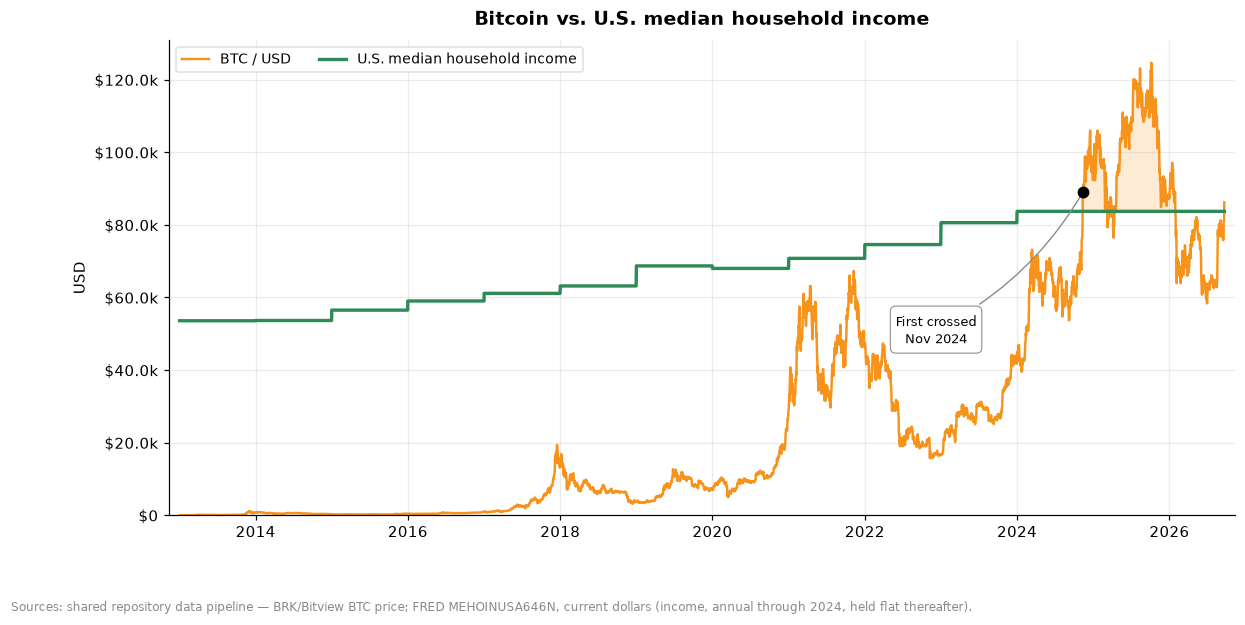

One bitcoin today  : $86.2k
Median income      : $83.7k  (2024, latest published)
A whole coin costs : 1.03x a year of median household income

Bitcoin first cost more than a year of median income in November 2024.
It has been above that line on 9% of days since 2013.

At $10.0k a year into Bitcoin, a whole coin at today's price would take 8.6 years of contributions — which is why the unit that matters is the satoshi.


In [5]:
MHI_PATH = INCOME_PATH

mhi = pd.read_csv(MHI_PATH)
mhi["date"] = pd.to_datetime(mhi["Year"].astype(int).astype(str) + "-01-01")
mhi = mhi.rename(columns={"median_household_income_usd": "income"})[["date", "income"]]
mhi = mhi.dropna().sort_values("date")
MHI_LAST_YEAR = int(mhi["date"].dt.year.max())
MHI_LATEST = float(mhi["income"].iloc[-1])

# Daily view of the price alongside the income line held flat between annual readings.
comp = PRICES[PRICES.index >= "2013-01-01"].to_frame("price")
comp["income"] = mhi.set_index("date")["income"].reindex(comp.index, method="ffill")
comp["income"] = comp["income"].ffill().fillna(float(mhi["income"].iloc[0]))

fig, ax = plt.subplots(figsize=(12.5, 6))
ax.plot(comp.index, comp["price"], color=ORANGE, lw=1.6, label="BTC / USD")
ax.plot(comp.index, comp["income"], color=GREEN, lw=2.2, label="U.S. median household income")
ax.fill_between(comp.index, comp["income"], comp["price"], where=comp["price"] > comp["income"],
                color=ORANGE, alpha=0.18)

crossed = comp[comp["price"] > comp["income"]]
if len(crossed):
    first = crossed.index[0]
    ax.scatter([first], [comp.loc[first, "price"]], s=45, color="black", zorder=6)
    ax.annotate(f"First crossed\n{first:%b %Y}", xy=(first, comp.loc[first, "price"]),
                xytext=(-96, -78), textcoords="offset points", fontsize=8.8,
                ha="center", va="top", linespacing=1.35,
                arrowprops=dict(arrowstyle="-", color=GREY, lw=0.9,
                                connectionstyle="arc3,rad=0.15"),
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=GREY, lw=0.7))

money_axis(ax); date_axis(ax, comp.index)
ax.set_ylabel("USD")
ax.set_ylim(bottom=0)
ax.set_title("Bitcoin vs. U.S. median household income")
ax.legend(loc="upper left", ncol=2)
ax.margins(x=0.01)
fig.subplots_adjust(bottom=0.16)
fig.text(0.01, 0.015,
         f"Sources: shared repository data pipeline — BRK/Bitview BTC price; "
         f"FRED MEHOINUSA646N, current dollars (income, annual through {MHI_LAST_YEAR}, "
         f"held flat thereafter).",
         fontsize=8, color=GREY, ha="left")
plt.show()

ratio = SPOT / MHI_LATEST
print(f"One bitcoin today  : {usd(SPOT)}")
print(f"Median income      : {usd(MHI_LATEST)}  ({MHI_LAST_YEAR}, latest published)")
print(f"A whole coin costs : {ratio:.2f}x a year of median household income")
if len(crossed):
    print(f"\nBitcoin first cost more than a year of median income in {crossed.index[0]:%B %Y}.")
    print(f"It has been above that line on {len(crossed)/len(comp):.0%} of days since 2013.")
else:
    print("\nBitcoin has not yet cost more than a year of median household income in this data.")
print(f"\nAt {usd(ANNUAL_BTC)} a year into Bitcoin, a whole coin at today's price would take "
      f"{SPOT/ANNUAL_BTC:.1f} years of contributions — which is why the unit that matters is the satoshi.")

## 4. The engine

Each buy date spends a fixed dollar amount at **that day's price** — never a later one. Cash earns interest
daily between deposits. Nothing looks into the future.

One measurement note. Comparing today's value to what you put in is misleading on its own, because money
arrived the whole way along — a dollar contributed last month hasn't had the same time to work as one from
the first year. So alongside the raw totals the tracker reports a **money-weighted return**: the annual rate
that accounts for when each dollar actually arrived. It can be positive or negative.

In [6]:
from functools import partial

run_plan = partial(simulate_plan, prices=PRICES, cash_apy=CASH_APY)

plan  = run_plan(PLAN_START, ANNUAL_BTC, ANNUAL_CASH, BUY_CADENCE,
                 still_buying=STILL_BUYING, stop_after_yrs=STOP_AFTER_YRS)
final = plan.iloc[-1]
BUYS = plan.attrs["buy_dates"]
BTC_AMOUNTS = plan.attrs["btc_contributions"]
TOTAL_AMOUNTS = plan.attrs["total_contributions"]
PER_BUY_BTC = BTC_AMOUNTS[-1]
IRR = money_weighted_return(BUYS, TOTAL_AMOUNTS, float(final["total_value"]), plan.index[-1])

STILL_BUYING_NOW = plan.attrs["still_contributing"]
print(f"Simulated {len(BUYS):,} purchases, {plan.index[0]:%b %Y} -> {BUYS[-1]:%b %Y}"
      + ("  (still contributing)" if STILL_BUYING_NOW else f"  (contributions ended {BUYS[-1]:%b %Y})") + ".")
if len(BUYS) < 6:
    print("Only a handful of purchases so far — the charts below will be sparse.")

Simulated 9 purchases, Jan 2026 -> Sep 2026  (still contributing).

## 5. Dashboard — where the plan stands

The summary of your plan as of the latest price date. Sections 6 to 10 show how most of these numbers were
arrived at; the money-weighted return is explained in Section 4 and not charted.

**Spot vs your basis** is the one to watch: it compares the current price to the average price you've paid.
Positive means the market is above your average, negative means below.

In [7]:
yrs_running = (plan.index[-1] - plan.index[0]).days / 365.25
basis = float(final["cost_basis"])
pl_dollars = float(final["total_value"] - final["total_contributed"])

dash = pd.DataFrame([
    ("Running for",           f"{yrs_running:.1f} years   ({len(BUYS):,} purchases)"),
    ("", ""),
    ("Bitcoin stacked",       f"{final['coins']:.4f} BTC"),
    ("In satoshis",           f"{sats(final['coins'])} sats"),
    ("Average price paid",    usd(basis)),
    ("Price now",             usd(final["price"])),
    ("Spot vs your basis",    f"{final['price']/basis-1:+.0%}"),
    (" ", ""),
    ("Contributed in total",  usd(final["total_contributed"])),
    ("   to Bitcoin",         usd(final["btc_contributed"])),
    ("   to cash",            usd(final["cash_contributed"])),
    ("  ", ""),
    ("Bitcoin now worth",     usd(final["btc_value"])),
    ("Cash now worth",        usd(final["cash_value"])),
    ("PORTFOLIO VALUE",       usd(final["total_value"])),
    ("Gain / loss",           f"{usd(pl_dollars)}   ({final['total_value']/final['total_contributed']-1:+.1%})"),
    ("Money-weighted return", f"{IRR:+.1%} per year" if np.isfinite(IRR) else "n/a"),
], columns=["", f"As of {plan.index[-1]:%d %b %Y}"])

dash.style.hide(axis="index")

,As of 21 Sep 2026
Running for,0.7 years (9 purchases)
,
Bitcoin stacked,0.1055 BTC
In satoshis,"10,545,302 sats"
Average price paid,$71.1k
Price now,$86.2k
Spot vs your basis,+21%
,
Contributed in total,$15.0k
to Bitcoin,$7.5k


## 6. Cost basis vs market price

**What this shows.** Your *cost basis* is the average price you've paid across every purchase to date. It's
plotted against the market price over the same period.

**How to read it.** Buying on a schedule makes the basis line move slowly, because each new purchase is only
a small share of the total. The market line moves fast. Green shading marks periods where the market sat
above your average, red where it sat below.

**The mechanism.** Whatever the shading looks like for your plan, the arithmetic is the same: a fixed dollar
amount buys more coins when the price is lower, which pulls your average down, and fewer when it's higher,
which pushes it up. You don't get the bottom, and you don't put everything in at the top.

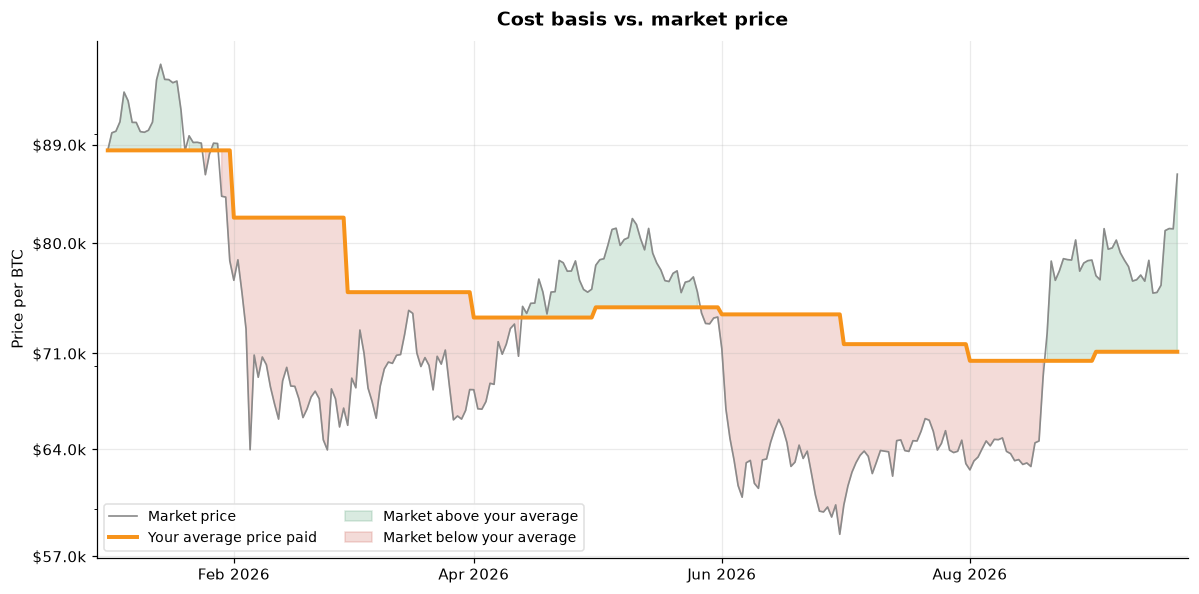

Average price paid : $71.1k
Market price now   : $86.2k   (+21% vs your basis)
Cheapest purchase  : $60.2k in Jul 2026
Priciest purchase  : $88.4k in Jan 2026

Since your first purchase, the market has been above your average on 39% of days.


In [8]:
fig, ax = plt.subplots()
ax.plot(plan.index, plan["price"], color=GREY, lw=1.1, label="Market price")
ax.plot(plan.index, plan["cost_basis"], color=ORANGE, lw=2.6, label="Your average price paid")
ax.fill_between(plan.index, plan["cost_basis"], plan["price"],
                where=plan["price"] >= plan["cost_basis"], color=GREEN, alpha=0.18,
                label="Market above your average")
ax.fill_between(plan.index, plan["cost_basis"], plan["price"],
                where=plan["price"] < plan["cost_basis"], color=RED, alpha=0.18,
                label="Market below your average")
ax.set_yscale("log")
money_axis(ax, log=True); date_axis(ax, plan.index)
ax.set_title("Cost basis vs. market price")
ax.set_ylabel("Price per BTC")
ax.legend(loc="lower left", ncol=2)
ax.margins(x=0.01)
plt.tight_layout(); plt.show()

buy_prices = pd.Series([float(PRICES.asof(d)) for d in BUYS],
                       index=pd.DatetimeIndex(BUYS), name="price")
# Days before the first purchase have no cost basis; excluding them keeps the share honest
# for plans that start mid-period.
live = plan.dropna(subset=["cost_basis"])
above = (live["price"] >= live["cost_basis"]).mean()
print(f"Average price paid : {usd(basis)}")
print(f"Market price now   : {usd(SPOT)}   ({SPOT/basis-1:+.0%} vs your basis)")
print(f"Cheapest purchase  : {usd(buy_prices.min())} in {buy_prices.idxmin():%b %Y}")
print(f"Priciest purchase  : {usd(buy_prices.max())} in {buy_prices.idxmax():%b %Y}")
print(f"\nSince your first purchase, the market has been above your average on {above:.0%} of days.")

## 7. Sats stacked, and sats per contribution

**What this shows.** The top panel is your running Bitcoin balance in satoshis (1 BTC = 100,000,000 sats),
with milestone lines marked as they're crossed. The bottom panel is how many sats each individual
contribution bought.

**How to read the bottom panel.** Bars are coloured against the median purchase for your plan — green means
that contribution bought more sats than your typical one, red means fewer. Because the dollar amount is
fixed, bar height is simply the inverse of price: lower price, taller bar.

This is the panel that shows what a falling market does to a scheduled buyer. Whether that has helped or hurt
your plan overall depends on your start date, and the numbers below tell you which.

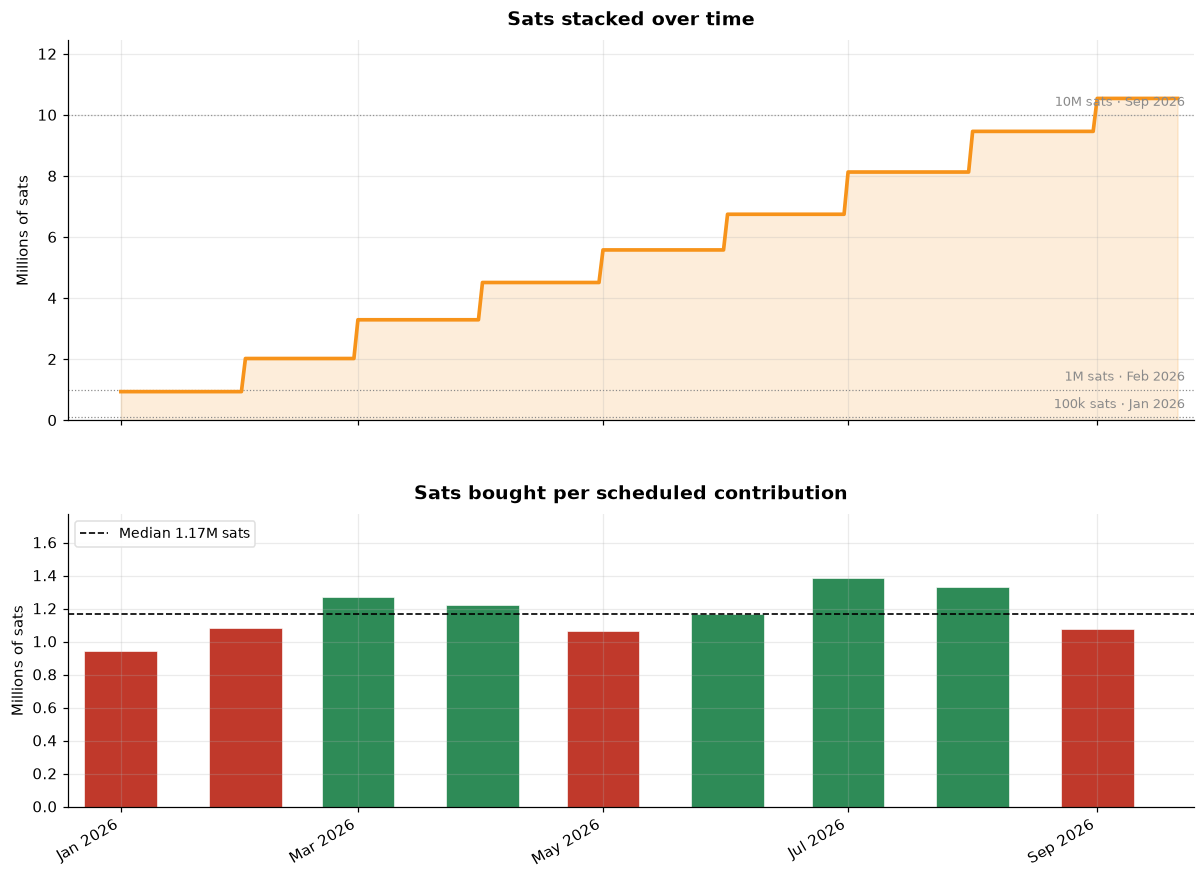

Total stacked : 10,545,302 sats
Best buy      : 1.38M sats in Jul 2026 at $60.2k
Worst buy     : 0.94M sats in Jan 2026 at $88.4k

Spread: the best contribution bought 1.5x more sats than the worst.


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(11.5, 8.6), sharex=True,
                         gridspec_kw={"height_ratios": [1.3, 1], "hspace": 0.28})

sats_held = plan["coins"] * 100          # millions of sats
axes[0].plot(plan.index, sats_held, color=ORANGE, lw=2.4)
axes[0].fill_between(plan.index, 0, sats_held, color=ORANGE, alpha=0.16)

top0 = max(float(sats_held.max()) * 1.18, 1.0)
MILESTONES = [(0.1, "100k sats"), (1.0, "1M sats"), (10.0, "10M sats"),
              (50.0, "50M sats"), (100.0, "1 BTC"), (200.0, "2 BTC")]
for level, label in spaced_levels(MILESTONES, top0, min_gap_frac=0.045):
    hit = plan[plan["coins"] * 100 >= level]
    axes[0].axhline(level, color=GREY, lw=0.8, ls=":", zorder=1)
    note = f"{label} · {hit.index[0]:%b %Y}" if len(hit) else f"{label} · not yet"
    axes[0].annotate(note, xy=(1.0, level), xycoords=("axes fraction", "data"),
                     xytext=(-6, 4), textcoords="offset points",
                     ha="right", va="bottom", fontsize=8.5, color=GREY, zorder=3)
axes[0].set_ylim(0, top0)
axes[0].set_ylabel("Millions of sats")
axes[0].set_title("Sats stacked over time")

bought = pd.Series(BTC_AMOUNTS, index=buy_prices.index) / buy_prices * 1e8
span_days = max((plan.index[-1] - plan.index[0]).days, 1)
bar_w = max(3.0, span_days / max(len(bought), 1) * 0.62)
axes[1].bar(bought.index, bought.values / 1e6, width=bar_w,
            color=[GREEN if v >= bought.median() else RED for v in bought],
            edgecolor="white", linewidth=0.4)
axes[1].axhline(bought.median() / 1e6, color="black", lw=1.1, ls="--", zorder=3,
                label=f"Median {bought.median()/1e6:.2f}M sats")
axes[1].set_ylim(0, float(bought.max()) / 1e6 * 1.28)
axes[1].set_ylabel("Millions of sats")
axes[1].legend(loc="upper left")
axes[1].set_title("Sats bought per scheduled contribution")

date_axis(axes[1], plan.index, rotate=30)
for a in axes:
    a.margins(x=0.015)
# tight_layout would fight the explicit hspace set on the gridspec
fig.subplots_adjust(left=0.085, right=0.975, top=0.94, bottom=0.13)
plt.show()

print(f"Total stacked : {sats(final['coins'])} sats")
print(f"Best buy      : {bought.max()/1e6:,.2f}M sats in {bought.idxmax():%b %Y} at {usd(buy_prices.loc[bought.idxmax()])}")
print(f"Worst buy     : {bought.min()/1e6:,.2f}M sats in {bought.idxmin():%b %Y} at {usd(buy_prices.loc[bought.idxmin()])}")
if len(bought) > 1 and bought.min() > 0:
    print(f"\nSpread: the best contribution bought {bought.max()/bought.min():.1f}x more sats than the worst.")

## 8. Milestones

**What this shows.** The article's satoshi ladder. Rungs already crossed show the month you reached them.
Rungs ahead show how far along you are and a rough arrival date.

**How the estimate works.** It assumes you keep contributing at your current rate and the price stays where
it is today. It is a pace calculation, not a forecast — a rising price pushes the date out, a falling price
pulls it in.

In [10]:
LADDER = [(0.001, "100k sats"), (0.01, "1M sats — satoshi millionaire"), (0.1, "10M sats"),
          (0.5, "50M sats — half a coin"), (1.0, "1 whole Bitcoin"), (2.0, "2 BTC"), (5.0, "5 BTC")]

# If contributions have stopped, there is no pace to project from.
coins_per_year = (ANNUAL_BTC / SPOT) if STILL_BUYING_NOW else 0.0
held = float(final["coins"])
rows = []
for level, name in LADDER:
    reached = plan[plan["coins"] >= level]
    if len(reached):
        status = f"reached {reached.index[0]:%b %Y}"
    else:
        status = milestone_status(level, held, ANNUAL_BTC, SPOT, plan.index[-1],
                                  STILL_BUYING_NOW, plan.attrs["stop_date"])
    rows.append({"Milestone": name, "BTC": f"{level:g}",
                 "Cost at spot": usd(level * SPOT), "Status": status})

print(f"Holding {sats(held)} sats.")
if STILL_BUYING_NOW:
    print(f"At {usd(PER_BUY_BTC)} {BUY_CADENCE} and a flat {usd(SPOT)} price, "
          f"you would stack about {coins_per_year*100:,.1f}M sats per year.\n")
else:
    print(f"Contributions ended {BUYS[-1]:%b %Y}, so no arrival dates are projected "
          f"for the rungs above.\n")
pd.DataFrame(rows).style.hide(axis="index")

Holding 10,545,302 sats.
At $833 monthly and a flat $86.2k price, you would stack about 11.6M sats per year.



Milestone,BTC,Cost at spot,Status
100k sats,0.001,$86,reached Jan 2026
1M sats — satoshi millionaire,0.01,$862,reached Feb 2026
10M sats,0.1,$8.6k,reached Sep 2026
50M sats — half a coin,0.5,$43.1k,21% there — about Feb 2030 at this pace
1 whole Bitcoin,1,$86.2k,11% there — about Jun 2034 at this pace
2 BTC,2,$172.4k,5% there — about Jan 2043 at this pace
5 BTC,5,$431.0k,2% there — about Nov 2068 at this pace


## 9. Portfolio value, and the cash comparison

**What this shows.** Three views, in two figures.

- **First figure, left:** your plan (orange) and a constant-APY cash scenario with the same contributions (green),
  both solid, with the money actually contributed as a dashed black line. Shading marks where the plan runs
  ahead of or behind that cash scenario.
- **First figure, right:** the same two totals as bars, plus their difference.
- **Second figure:** the distance between your portfolio and your contributions, every day — above zero means
  the plan is worth more than you put in, below zero means less.

**How to read it.** Two separate questions live here, and they can have different answers:

1. *Is the plan ahead of what I contributed?* — the second figure.
2. *Is the plan ahead of simply saving cash?* — the gap between the orange and green lines, and the
   "Difference" bar.

The table underneath values the identical plan on its best day, its worst day, and today, so you can see how
much of the current reading is the plan and how much is the date you happen to be looking at.

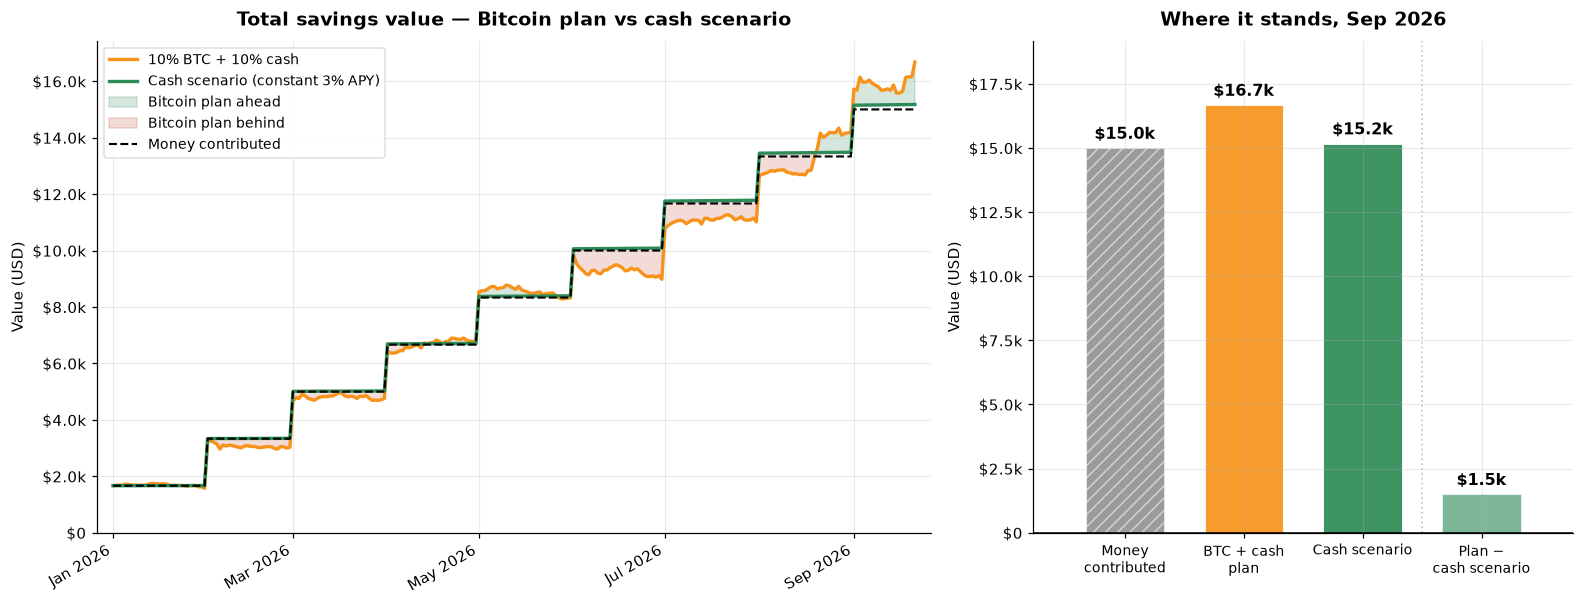

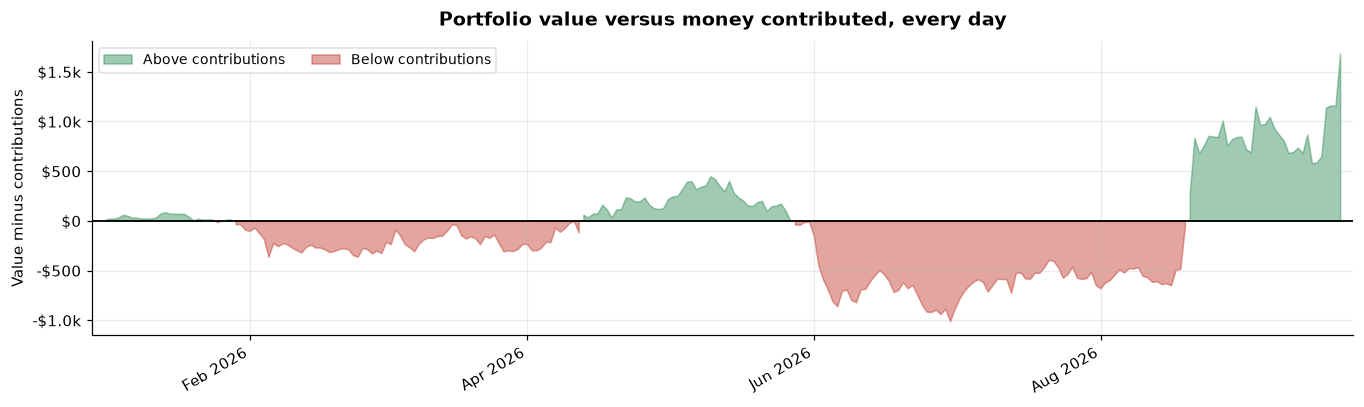

Versus the constant-3.0% cash scenario: $1.5k ahead
   cash scenario: $15.2k from $15.0k contributed   (+3.0%/yr money-weighted)
   this plan : $16.7k from $15.0k contributed   (+30.7%/yr money-weighted)

Below contributions on 160 of 264 days (61% of the time since your first purchase).

The same plan, valued on three different days:

              Moment        Date BTC price Plan worth vs contributed
 Best reading so far 21 Sep 2026    $86.2k     $16.7k           +11%
Worst reading so far 05 Feb 2026    $64.0k      $3.0k           -11%
         Latest data 21 Sep 2026    $86.2k     $16.7k           +11%


In [11]:
cash_only = run_plan(PLAN_START, 0.0, ANNUAL_BTC + ANNUAL_CASH, BUY_CADENCE,
                     still_buying=STILL_BUYING, stop_after_yrs=STOP_AFTER_YRS)
co_final = cash_only.iloc[-1]

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.6), gridspec_kw={"width_ratios": [1.7, 1.1]})

# -- left: the two plans side by side, with the difference shaded
axes[0].plot(plan.index, plan["total_value"], color=ORANGE, lw=2.2,
             label=f"{PCT_TO_BITCOIN:.0%} BTC + {PCT_TO_CASH:.0%} cash")
axes[0].plot(cash_only.index, cash_only["total_value"], color=GREEN, lw=2.2,
             label=f"Cash scenario (constant {CASH_APY:.0%} APY)")
axes[0].fill_between(plan.index, cash_only["total_value"], plan["total_value"],
                     where=plan["total_value"] >= cash_only["total_value"],
                     color=GREEN, alpha=0.20, label="Bitcoin plan ahead")
axes[0].fill_between(plan.index, cash_only["total_value"], plan["total_value"],
                     where=plan["total_value"] < cash_only["total_value"],
                     color=RED, alpha=0.18, label="Bitcoin plan behind")
axes[0].plot(plan.index, plan["total_contributed"], color="black", ls="--", lw=1.4,
             label="Money contributed")
money_axis(axes[0]); date_axis(axes[0], plan.index, rotate=30)
axes[0].set_ylabel("Value (USD)")
axes[0].legend(loc="upper left")
axes[0].margins(x=0.02)
axes[0].set_ylim(bottom=0)
axes[0].set_title("Total savings value — Bitcoin plan vs cash scenario")

# -- right: the same lines as bars, so the two panels read against each other.
# "Money contributed" is the dashed reference line on the left, carried over here.
excess = float(final["total_value"] - co_final["total_value"])
bars = [("Money\ncontributed", float(final["total_contributed"]), "#4A4A4A", 0.55),
        ("BTC + cash\nplan",   float(final["total_value"]),       ORANGE,    0.92),
        ("Cash scenario",       float(co_final["total_value"]),    GREEN,     0.92),
        ("Plan −\ncash scenario", excess, GREEN if excess >= 0 else RED,     0.62)]
for i, (lbl, val, colour, alpha) in enumerate(bars):
    axes[1].bar(i, val, color=colour, alpha=alpha, width=0.66,
                edgecolor="white", linewidth=0.6,
                hatch="///" if i == 0 else None)
    axes[1].annotate(f"{usd(val)}", xy=(i, val), xytext=(0, 6 if val >= 0 else -16),
                     textcoords="offset points", ha="center", fontsize=10.5, fontweight="bold")
# separate the derived difference from the three level readings
axes[1].axvline(2.5, color="#CCCCCC", lw=1.2, ls=":", zorder=0)
axes[1].axhline(0, color="black", lw=1)
axes[1].set_xticks(range(len(bars))); axes[1].set_xticklabels([b[0] for b in bars], fontsize=9)
money_axis(axes[1])
axes[1].set_ylabel("Value (USD)")
_lo = min(0.0, min(b[1] for b in bars) * 1.55)
_hi = max(b[1] for b in bars) * 1.15
axes[1].set_ylim(_lo, _hi)
axes[1].margins(x=0.12)
axes[1].set_title(f"Where it stands, {plan.index[-1]:%b %Y}")
plt.tight_layout(); plt.show()

# -- the day-by-day distance from contributions
fig, ax = plt.subplots(figsize=(12.5, 3.8))
surplus = plan["total_value"] - plan["total_contributed"]
ax.fill_between(plan.index, 0, surplus, where=surplus >= 0, color=GREEN, alpha=0.45,
                label="Above contributions")
ax.fill_between(plan.index, 0, surplus, where=surplus < 0, color=RED, alpha=0.45,
                label="Below contributions")
ax.axhline(0, color="black", lw=1.2)
money_axis(ax); date_axis(ax, plan.index, rotate=30)
ax.set_ylabel("Value minus contributions")
ax.legend(loc="upper left", ncol=2)
ax.margins(x=0.01)
ax.set_title("Portfolio value versus money contributed, every day")
plt.tight_layout(); plt.show()

gap = float(final["total_value"] - co_final["total_value"])
CASH_BUYS = cash_only.attrs["buy_dates"]
CASH_AMOUNTS = cash_only.attrs["total_contributions"]
IRR_CASH = money_weighted_return(CASH_BUYS, CASH_AMOUNTS,
                                 float(co_final["total_value"]), cash_only.index[-1])
under = live[live["total_value"] < live["total_contributed"]]
print(f"Versus the constant-{CASH_APY:.1%} cash scenario: {usd(abs(gap))} {'ahead' if gap > 0 else 'behind'}")
_r = lambda v: f"{v:+.1%}/yr" if np.isfinite(v) else "n/a"
print(f"   cash scenario: {usd(co_final['total_value'])} from {usd(co_final['total_contributed'])} contributed"
      f"   ({_r(IRR_CASH)} money-weighted)")
print(f"   this plan : {usd(final['total_value'])} from {usd(final['total_contributed'])} contributed"
      f"   ({_r(IRR)} money-weighted)")
print(f"\nBelow contributions on {len(under):,} of {len(live):,} days "
      f"({len(under)/max(len(live),1):.0%} of the time since your first purchase).")

# Select on the same measure the table reports, so the "best" row really is the best one shown.
rel = plan["total_value"] / plan["total_contributed"]
best_day, worst_day = rel.idxmax(), rel.idxmin()
swing = pd.DataFrame([
    {"Moment": lbl, "Date": f"{d:%d %b %Y}", "BTC price": usd(plan.loc[d, "price"]),
     "Plan worth": usd(plan.loc[d, "total_value"]),
     "vs contributed": f"{plan.loc[d,'total_value']/plan.loc[d,'total_contributed']-1:+.0%}"}
    for lbl, d in [("Best reading so far", best_day), ("Worst reading so far", worst_day),
                   ("Latest data", plan.index[-1])]
])
print("\nThe same plan, valued on three different days:\n")
print(swing.to_string(index=False))

### How to interpret the bottom panel

Red stretches are a normal feature of this strategy, not by themselves a signal that it has failed. A
scheduled buyer into a volatile asset should expect to spend meaningful time below their contributions, and
those are also the periods when each contribution buys the most sats. The percentage printed above tells you
how much of your own plan's life that has been.

Equally, a green reading is not proof the strategy worked. Both are snapshots of one day, which is what the
three-row table above is there to demonstrate.

The variable that matters most in either direction is **how long the plan has been running**. A plan measured
over a year or two is dominated by where the price happened to be at the start and end. The article's case
rests on a horizon measured in decades, and short windows should be read with that in mind.

## 10. Year-by-year breakdown

**What this shows.** The same plan resolved to calendar years instead of days. The left panel stacks the cash
and Bitcoin halves at each year-end with the combined total marked on top; the right panel is the coin balance
itself, in BTC rather than dollars, with reference lines at the half-coin and whole-coin marks.

**How to read it.** The stacked bars separate the two things a savings plan does: the green block grows with
contributions plus interest and never falls, while the orange block moves with the market. Comparing the two
across years shows how much of the total is money you put in versus price.

The first bar is the year before the plan started, included as a zero baseline. If contributions have
stopped, the green block keeps growing on interest alone.

The year-end table underneath gives the same information as numbers. The final row is the current year, which
is only complete up to the latest price date.

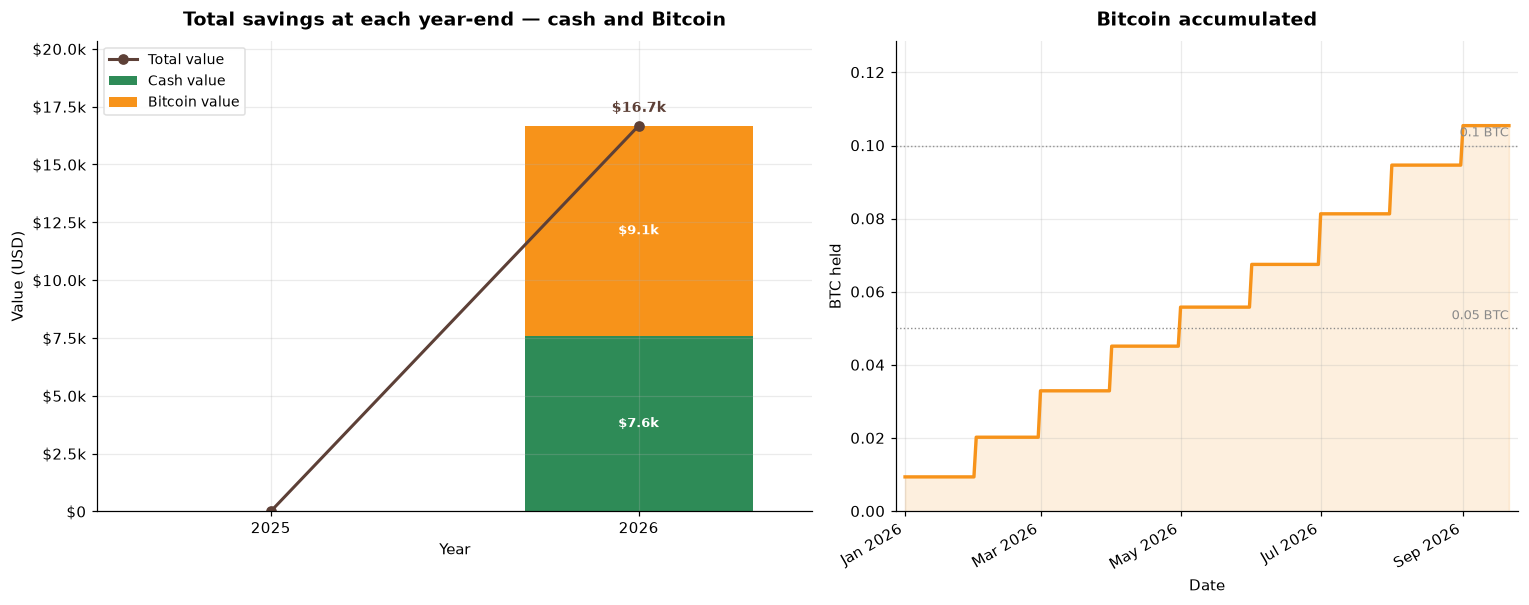

In [12]:
# Year-end snapshots. The year before the plan starts is included as a zero baseline,
# and the final year is truncated at the latest available date.
years = list(range(plan.index[0].year, plan.index[-1].year + 1))
snapshots = []
base_year = plan.index[0].year - 1
snapshots.append({"year": base_year, "coins": 0.0, "btc_value": 0.0, "cash_value": 0.0,
                  "contributed": 0.0, "total": 0.0, "partial": False})
for y in years:
    in_year = plan[plan.index.year == y]
    if not len(in_year):
        continue
    r = in_year.iloc[-1]
    snapshots.append({"year": y, "coins": float(r["coins"]), "btc_value": float(r["btc_value"]),
                      "cash_value": float(r["cash_value"]), "contributed": float(r["total_contributed"]),
                      "total": float(r["total_value"]),
                      "partial": (y == plan.index[-1].year
                                  and plan.index[-1] < pd.Timestamp(year=y, month=12, day=31))})
ye = pd.DataFrame(snapshots)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), gridspec_kw={"width_ratios": [1.15, 1]})

axes[0].bar(ye["year"], ye["cash_value"], color=GREEN, label="Cash value", width=0.62)
axes[0].bar(ye["year"], ye["btc_value"], bottom=ye["cash_value"], color=ORANGE,
            label="Bitcoin value", width=0.62)
axes[0].plot(ye["year"], ye["total"], color="#5D4037", marker="o", lw=2, label="Total value")
for _, r in ye.iterrows():
    if r["total"] > 0:
        axes[0].annotate(f"{usd(r['total'])}", xy=(r["year"], r["total"]), xytext=(0, 9),
                         textcoords="offset points", ha="center", fontsize=9,
                         fontweight="bold", color="#5D4037")
        if r["cash_value"] > 0:
            axes[0].annotate(f"{usd(r['cash_value'])}", xy=(r["year"], r["cash_value"] / 2),
                             ha="center", va="center", fontsize=8.5, color="white", fontweight="bold")
        if r["btc_value"] > r["total"] * 0.09:
            axes[0].annotate(f"{usd(r['btc_value'])}",
                             xy=(r["year"], r["cash_value"] + r["btc_value"] / 2),
                             ha="center", va="center", fontsize=8.5, color="white", fontweight="bold")
money_axis(axes[0])
axes[0].set_xticks(ye["year"]); axes[0].set_xticklabels([int(y) for y in ye["year"]], rotation=0)
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Value (USD)")
axes[0].set_ylim(0, max(ye["total"].max() * 1.22, 1))
axes[0].legend(loc="upper left")
axes[0].margins(x=0.10)
axes[0].set_title("Total savings at each year-end — cash and Bitcoin")

axes[1].plot(plan.index, plan["coins"], color=ORANGE, lw=2.2)
axes[1].fill_between(plan.index, 0, plan["coins"], color=ORANGE, alpha=0.14)
top = max(float(plan["coins"].max()) * 1.22, 0.05)
for level, lbl in spaced_levels([(0.05, "0.05 BTC"), (0.1, "0.1 BTC"), (0.25, "0.25 BTC"),
                                 (0.5, "0.5 BTC"), (1.0, "1.0 BTC"), (2.0, "2.0 BTC"),
                                 (5.0, "5.0 BTC")], top, min_gap_frac=0.14):
    axes[1].axhline(level, color=GREY, lw=0.9, ls=":", zorder=1)
    axes[1].annotate(lbl, xy=(1.0, level), xycoords=("axes fraction", "data"),
                     xytext=(-6, 4), textcoords="offset points",
                     ha="right", va="bottom", fontsize=8.5, color=GREY)
axes[1].set_ylim(0, top)
axes[1].set_ylabel("BTC held"); axes[1].set_xlabel("Date")
axes[1].set_title("Bitcoin accumulated")
date_axis(axes[1], plan.index, rotate=30)
axes[1].margins(x=0.015)
plt.tight_layout(); plt.show()

In [13]:
table = pd.DataFrame([{
    "Year":            f"{int(r['year'])}" + (" (partial)" if r["partial"] else ""),
    "Total saved":     usd(r["contributed"]),
    "BTC held":        f"{r['coins']:.4f}",
    "BTC value":       usd(r["btc_value"]),
    "Cash":            usd(r["cash_value"]),
    "Savings value":   usd(r["total"]),
    "vs contributed":  "—" if r["contributed"] == 0 else f"{r['total']/r['contributed']-1:+.0%}",
} for _, r in ye.iterrows()])

print(f"Year-end breakdown — {PCT_TO_BITCOIN:.0%} Bitcoin / {PCT_TO_CASH:.0%} cash "
      f"on ${ANNUAL_INCOME:,} income, bought {BUY_CADENCE}\n")
if ye["partial"].any():
    print(f"The final row is year-to-date through {plan.index[-1]:%d %b %Y}, not a full year.\n")
table.style.hide(axis="index")

Year-end breakdown — 10% Bitcoin / 10% cash on $100,000 income, bought monthly

The final row is year-to-date through 21 Sep 2026, not a full year.



Year,Total saved,BTC held,BTC value,Cash,Savings value,vs contributed
2025,$0,0.0000,$0,$0,$0,—
2026 (partial),$15.0k,0.1055,$9.1k,$7.6k,$16.7k,+11%


## 11. Does the buying schedule matter?

**What this shows.** The identical plan run at three cadences — weekly, bi-weekly and monthly.

**A note on making this fair.** A calendar window does not divide evenly into weeks and months, so
running each cadence at its natural per-purchase amount contributes slightly different totals and the
comparison would be measuring budget as much as rhythm. Each cadence below is therefore rebalanced to spend
the **same total** as your configured plan, spread across however many purchases that cadence makes.

In [14]:
TARGET_BTC_SPEND = float(final["btc_contributed"])
TARGET_CASH_SPEND = float(final["cash_contributed"])

rows = []
for cad in ["weekly", "biweekly", "monthly"]:
    # First measure how much one annual dollar contributes over this exact window,
    # then scale so every cadence deploys the configured plan's identical total.
    unit = run_plan(PLAN_START, 1.0, 1.0, cad, still_buying=STILL_BUYING,
                    stop_after_yrs=STOP_AFTER_YRS)
    n = len(unit.attrs["buy_dates"])
    unit_final = unit.iloc[-1]
    scaled_btc = TARGET_BTC_SPEND / float(unit_final["btc_contributed"])
    scaled_cash = TARGET_CASH_SPEND / float(unit_final["cash_contributed"])
    p = run_plan(PLAN_START, scaled_btc, scaled_cash, cad,
                 still_buying=STILL_BUYING, stop_after_yrs=STOP_AFTER_YRS)
    f = p.iloc[-1]
    rows.append({"Cadence": cad.capitalize(), "Purchases": f"{n:,}",
                 "Contributed": usd(f["total_contributed"]),
                 "BTC stacked": f"{f['coins']:.4f}", "Avg price paid": usd(f["cost_basis"]),
                 "Bitcoin value": usd(f["btc_value"]), "Total value": usd(f["total_value"]),
                 "_btc": float(f["btc_value"]), "_v": float(f["total_value"])})
tbl = pd.DataFrame(rows)
print(tbl.drop(columns=["_btc", "_v"]).to_string(index=False))

# Cadence only moves the Bitcoin leg — the cash leg receives the same total either way — so the
# effect is quoted against Bitcoin value as well as the diluted whole-portfolio figure.
btc_spread = tbl["_btc"].max() - tbl["_btc"].min()
tot_spread = tbl["_v"].max() - tbl["_v"].min()
print(f"\nSpread across cadences, Bitcoin leg : {usd(btc_spread)} ({btc_spread/tbl['_btc'].min():.1%})")
print(f"Spread across cadences, whole plan  : {usd(tot_spread)} ({tot_spread/tbl['_v'].min():.1%})")
print(f"Best-to-worst swing across dates (Section 9): {usd(surplus.max()-surplus.min())}")

 Cadence Purchases Contributed BTC stacked Avg price paid Bitcoin value Total value
  Weekly        38      $15.0k      0.1039         $72.2k         $9.0k      $16.5k
Biweekly        19      $15.0k      0.1036         $72.4k         $8.9k      $16.5k
 Monthly         9      $15.0k      0.1055         $71.1k         $9.1k      $16.7k

Spread across cadences, Bitcoin leg : $159 (1.8%)
Spread across cadences, whole plan  : $165 (1.0%)
Best-to-worst swing across dates (Section 9): $2.7k


## 12. The long view

**What this shows.** Bitcoin's full price history on a log scale, with your plan's window shaded. The point
is scale: it shows how much of the available price record your plan actually covers.

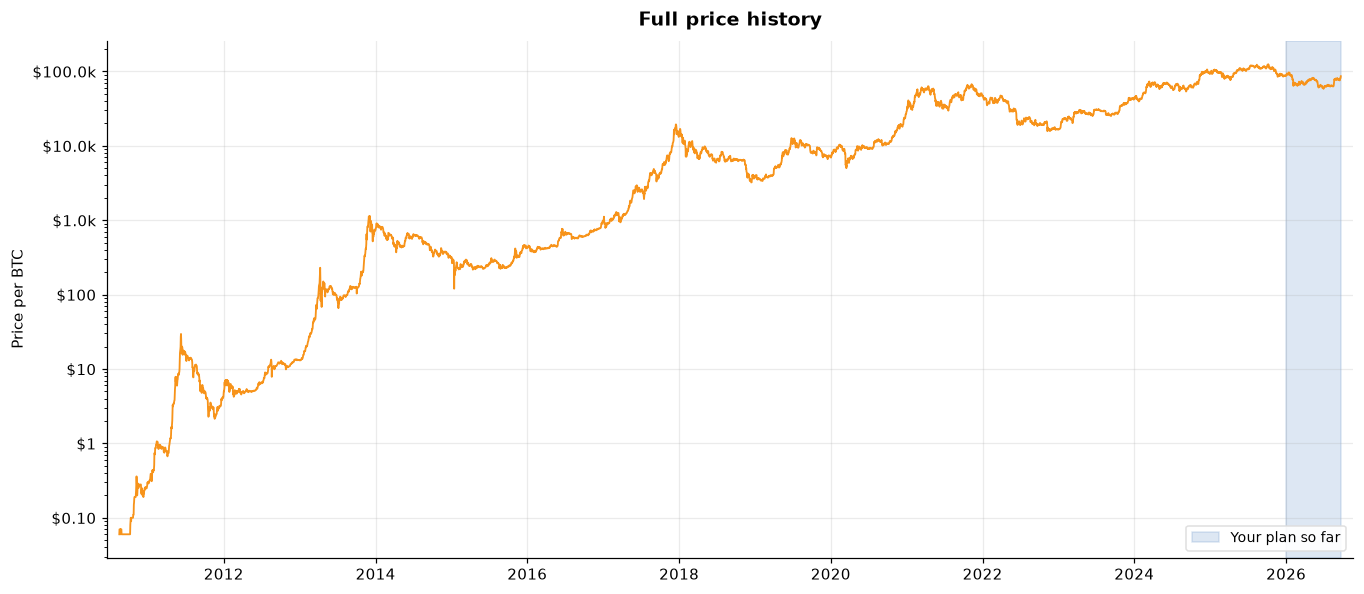

Price history spans 16 years. Your plan covers 0.7 of them (4%).


In [15]:
fig, ax = plt.subplots(figsize=(12.5, 5.5))
ax.plot(PRICES.index, PRICES.values, color=ORANGE, lw=1.2)
ax.axvspan(plan.index[0], plan.index[-1], color=BLUE, alpha=0.16, label="Your plan so far")
ax.set_yscale("log")
money_axis(ax, log=True); date_axis(ax, PRICES.index)
ax.set_ylabel("Price per BTC")
ax.set_title("Full price history")
ax.legend(loc="lower right")
ax.margins(x=0.01)
plt.tight_layout(); plt.show()

span = (TODAY - PRICES.index[0]).days / 365.25
print(f"Price history spans {span:.0f} years. Your plan covers {yrs_running:.1f} of them ({yrs_running/span:.0%}).")

## 13. Reference

### Running the strategy

1. **Pick your percentage.** The article uses 10% to Bitcoin and 10% to cash. A smaller share you can sustain
   through a drawdown is worth more than an aggressive one you abandon.
2. **Automate it.** Cash App, Strike. Automating removes the recurring decision, which is where
   savers tend to do themselves the most damage.
3. **Pick a cadence and leave it.** Section 11 quantifies how little the choice matters for your own plan.
4. **Count in sats.** Section 8 gives you rungs sized to your actual contribution rate.
5. **Withdraw to your own wallet** once the balance matters to you.

**Risk:** Bitcoin can lose most or all of its value; platforms can fail, and lost keys can mean permanent
loss. Keep emergency liquidity, avoid over-concentration, and use self-custody only if you can secure it.

### Running this tracker

- Run `scripts/update_data.py` once to refresh the shared release, then run this notebook top to bottom.
- Your settings live in Section 1. Change them freely — nothing is cached, so every run rebuilds cleanly
  from scratch against whatever you set.
- Section 5 is the dashboard. Sections 6 to 10 show how it got there.
- Monthly is a sensible rhythm. Checking daily works against the strategy.

### What the tracker reports, and what it doesn't

**It reports** where your plan stands on real price history: sats accumulated, average price paid, value
against contributions, and a like-for-like constant-APY cash scenario — measured with
a money-weighted return rather than a naive percentage.

**It doesn't forecast a price**, and the strategy doesn't require one. Nothing in this notebook assumes the
result will be positive. The outcome depends on your start date, your horizon, and what the market does,
and the numbers shown are simply what your inputs produce against the data available. Results are nominal,
pre-fee and pre-tax. The cash comparison is a constant-APY scenario, not a historical savings-rate series.

*Research and education only. Not investment advice.*

## 14. Quarterly report — savings cohorts

This section exports the reporting year and four preceding starter cohorts using
the contribution assumptions from Section 1. The latest bundle is published in
`outputs/savings/latest/` with data, three charts, and a checksum manifest.
Read `section3_packet.json` first. Git history preserves each published snapshot.
For a quarterly newsletter, select a commit whose report date is the quarter end;
interim daily results are not a completed quarterly report.


In [16]:
# Contribution assumptions come from Section 1; None selects the saved release date.
REPORT_AS_OF = None                 # e.g. "2026-09-30", once that data exists
REPORT_COHORT_YEARS = None           # report year and previous four years

from IPython.display import display, Image
from bitcoin_investment_strategy.savings_report import export_report

section3_output, section3_plan, section3_tables = export_report(
    ROOT, as_of=REPORT_AS_OF, cohort_years=REPORT_COHORT_YEARS,
    annual_income=ANNUAL_INCOME, bitcoin_fraction=PCT_TO_BITCOIN,
    cash_fraction=PCT_TO_CASH, cash_apy=CASH_APY, cadence=BUY_CADENCE,
    still_buying=STILL_BUYING, stop_after_yrs=STOP_AFTER_YRS,
)
print(f"Section 3: {section3_plan['snapshot_status']} through {section3_plan['report_date']}")
print(f"Export bundle: {section3_output.relative_to(ROOT)}")
print("Agent entry point: section3_packet.json")
print("Since-start savings results")
summary = section3_tables["cohort_summary"].rename(columns={
    "cohort_year": "Start year", "total_contributed_usd": "Contributed",
    "btc_held": "BTC held", "total_value_usd": "Plan value",
    "total_gain_usd": "Gain / loss", "advantage_vs_cash_usd": "Vs cash",
})
display(summary[["Start year", "Contributed", "BTC held", "Plan value", "Gain / loss", "Vs cash"]]
        .style.hide(axis="index").format({"BTC held": "{:.6f}", **{
            c: "${:,.0f}" for c in ["Contributed", "Plan value", "Gain / loss", "Vs cash"]}}))
print("YTD: opening savings + new contributions + investment gain/loss = closing savings")
ytd = section3_tables["ytd_summary"].rename(columns={
    "cohort_year": "Start year", "opening_total_value_usd": "Opening value",
    "total_contributed_ytd_usd": "New savings", "total_gain_ytd_usd": "YTD gain / loss",
    "closing_total_value_usd": "Closing value", "incremental_advantage_ytd_usd": "YTD edge vs cash",
})
cols = ["Opening value", "New savings", "YTD gain / loss", "Closing value", "YTD edge vs cash"]
display(ytd[["Start year", *cols]].style.hide(axis="index").format({c: "${:,.0f}" for c in cols}))


Section 3: interim through 2026-09-21
Export bundle: outputs/savings/latest
Agent entry point: section3_packet.json
Since-start savings results


Start year,Contributed,BTC held,Plan value,Gain / loss,Vs cash
2026,"$15,000",0.105453,"$16,677","$1,677","$1,503"
2025,"$35,000",0.205769,"$35,705",$705,$-231
2024,"$55,000",0.371016,"$60,642","$5,642","$3,322"
2023,"$75,000",0.744867,"$103,881","$28,881","$24,534"
2022,"$95,000",1.124216,"$147,925","$52,925","$45,890"


YTD: opening savings + new contributions + investment gain/loss = closing savings


Start year,Opening value,New savings,YTD gain / loss,Closing value,YTD edge vs cash
2026,$0,"$15,000","$1,677","$16,677","$1,503"
2025,"$18,918","$15,000","$1,787","$35,705","$1,174"
2024,"$43,809","$15,000","$1,833","$60,642",$768
2023,"$87,224","$15,000","$1,657","$103,881",$127
2022,"$131,442","$15,000","$1,483","$147,925",$-527


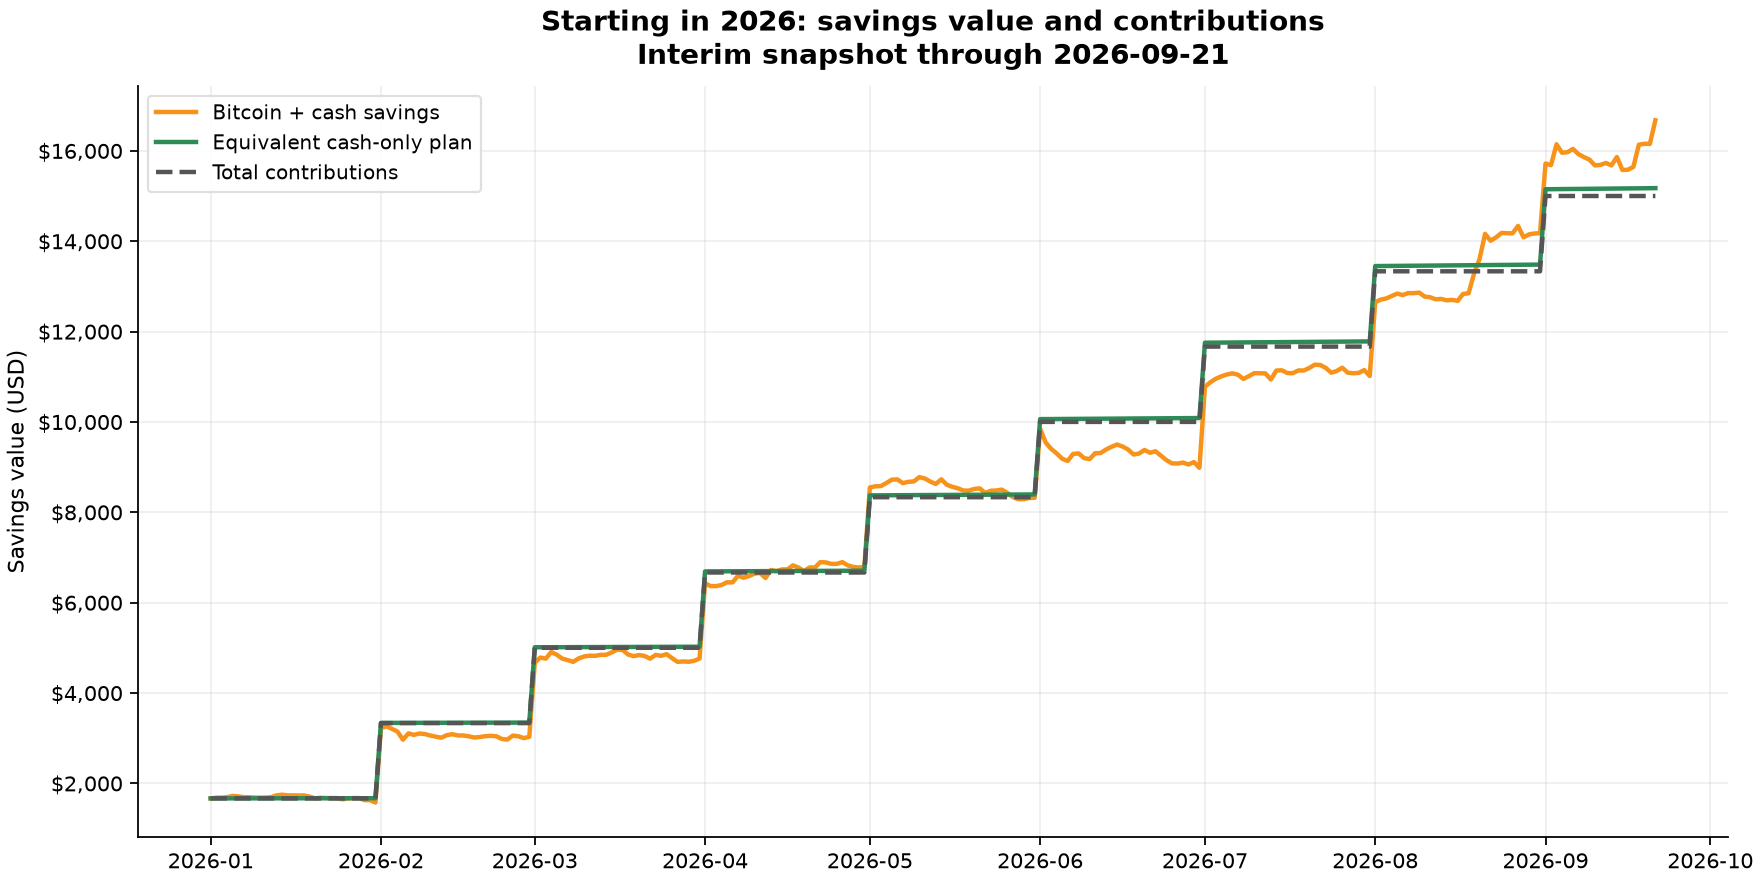

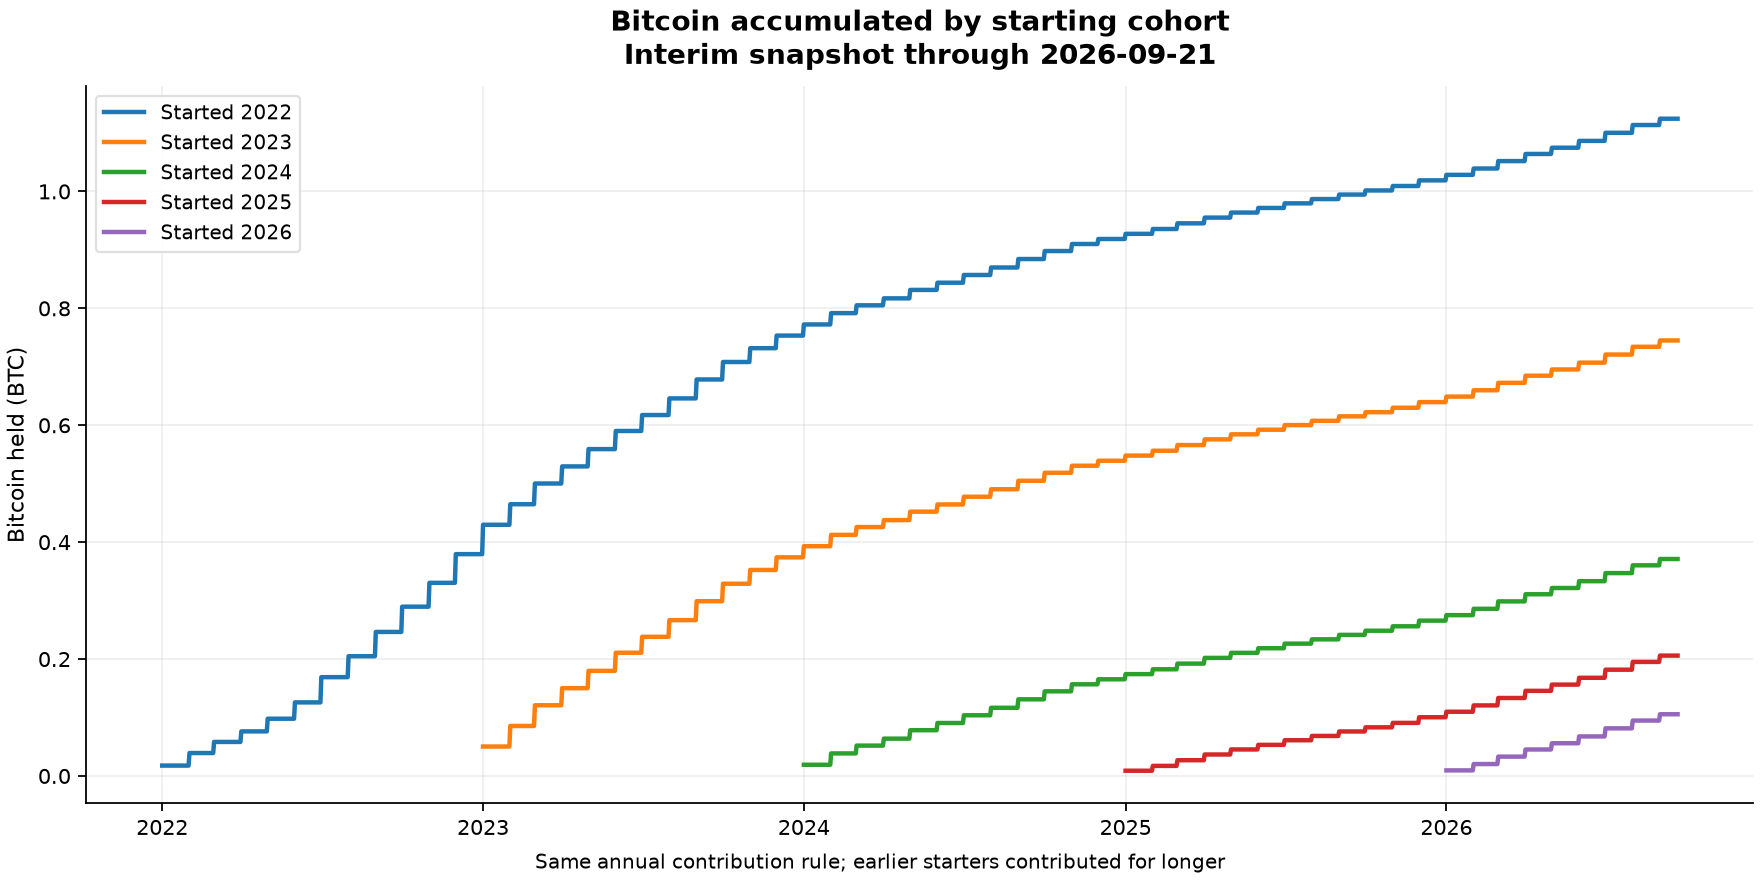

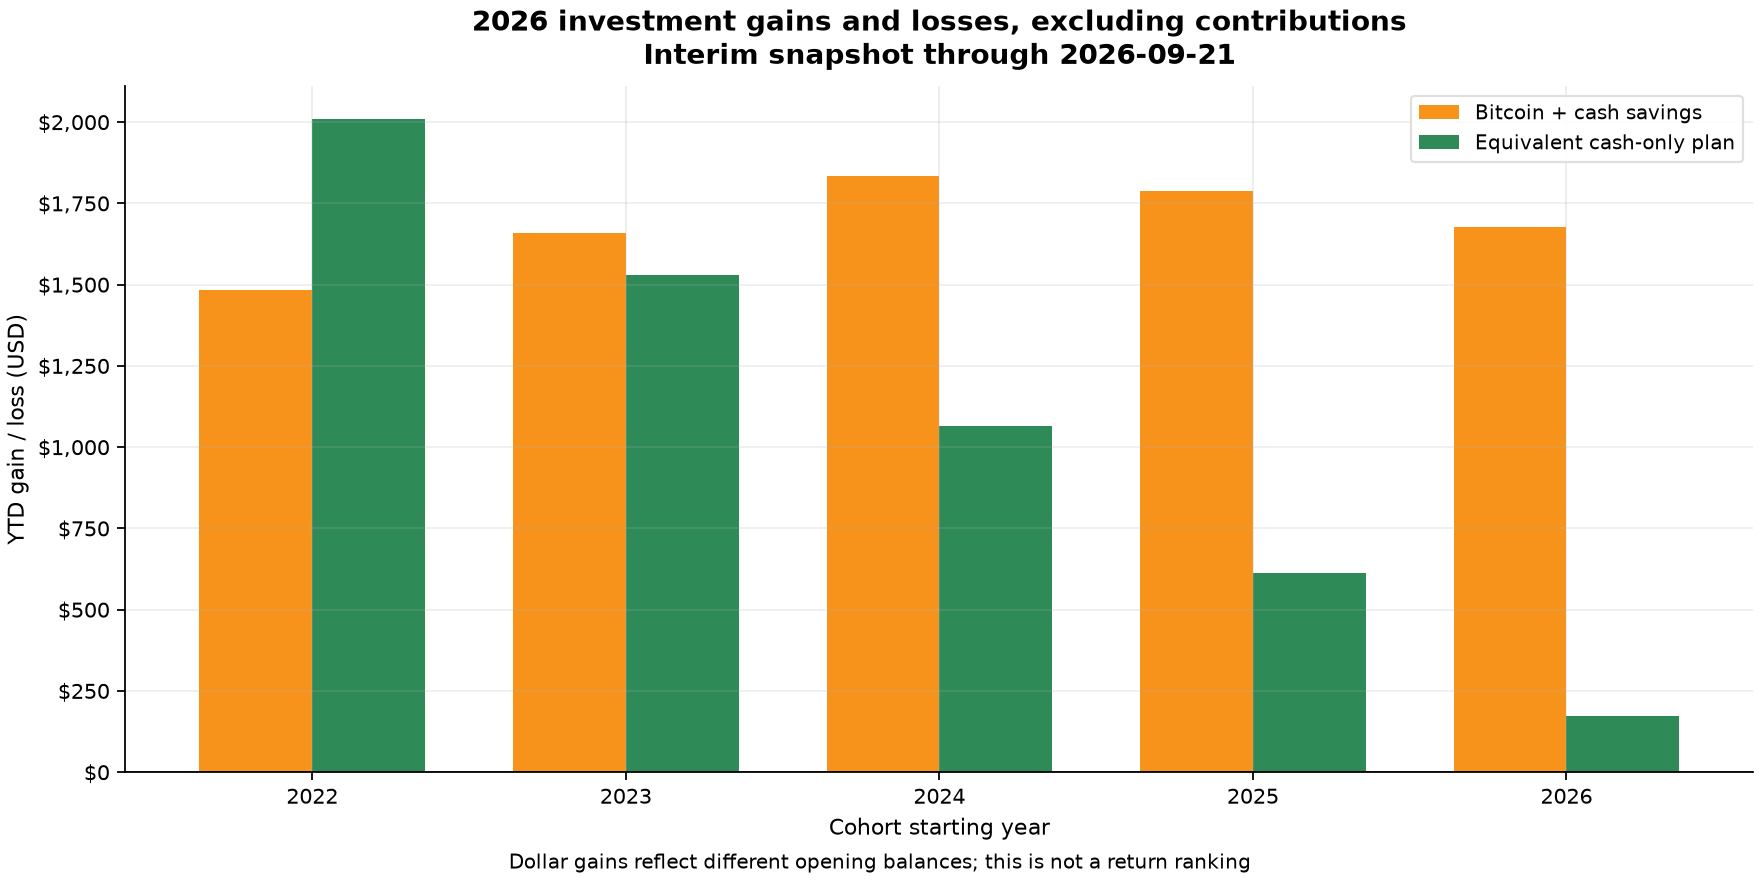

In [17]:
for filename in ["current_year_savings.png", "cohort_accumulation.png", "ytd_gains_vs_cash.png"]:
    display(Image(filename=str(section3_output / filename), width=1000))
